In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
df = pd.read_csv("../data/processed/olist_orders_abt.csv")
df.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,...,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,...,38.71,1.0,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,...,141.46,1.0,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,...,179.12,3.0,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,...,72.20,1.0,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,...,28.62,1.0,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [3]:
 df.shape

(99441, 29)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  99441 non-null  str    
 1   customer_id               99441 non-null  str    
 2   customer_unique_id        99441 non-null  str    
 3   customer_city             99441 non-null  str    
 4   customer_state            99441 non-null  str    
 5   order_status              99441 non-null  str    
 6   order_year                99441 non-null  int64  
 7   order_month               99441 non-null  int64  
 8   order_day                 99441 non-null  int64  
 9   order_day_of_week         99441 non-null  int64  
 10  order_hour                99441 non-null  int64  
 11  delivery_days             96476 non-null  float64
 12  estimated_delivery_days   99441 non-null  int64  
 13  delivery_delay_days       96476 non-null  float64
 14  is_late_delivery 

In [6]:
df.describe()

,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,...,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,total_items,total_price,total_freight,unique_products,unique_sellers
count,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,96476.000000,99441.000000,96476.000000,99441.000000,98673.000000,...,98673.000000,98673.000000,99440.000000,99440.000000,99440.000000,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000
mean,2017.539838,6.032220,15.505948,2.755735,14.770829,12.094086,23.403958,-11.876881,0.065717,4.086793,...,0.415281,0.413852,160.990267,2.930521,1.022586,1.141731,137.754076,22.823562,1.038098,1.013622
std,0.505007,3.232999,8.667298,1.966495,5.326800,9.551746,8.829562,10.183854,0.247789,1.346274,...,0.495685,0.492525,221.951257,2.715685,0.148582,0.538452,210.645145,21.650909,0.226456,0.122297
min,2016.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,-147.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.850000,0.000000,1.000000,1.000000
25%,2017.000000,3.000000,8.000000,1.000000,11.000000,6.000000,18.000000,-17.000000,0.000000,4.000000,...,0.000000,0.000000,62.010000,1.000000,1.000000,1.000000,45.900000,13.850000,1.000000,1.000000
50%,2018.000000,6.000000,15.000000,3.000000,15.000000,10.000000,23.000000,-12.000000,0.000000,5.000000,...,0.000000,0.000000,105.290000,2.000000,1.000000,1.000000,86.900000,17.170000,1.000000,1.000000
75%,2018.000000,8.000000,23.000000,4.000000,19.000000,15.000000,28.000000,-7.000000,0.000000,5.000000,...,1.000000,1.000000,176.970000,4.000000,1.000000,1.000000,149.900000,24.040000,1.000000,1.000000
max,2018.000000,12.000000,31.000000,6.000000,23.000000,209.000000,155.000000,188.000000,1.000000,5.000000,...,3.000000,1.000000,13664.080000,24.000000,2.000000,21.000000,13440.000000,1794.960000,8.000000,5.000000


In [7]:
nominal_columns = [
    "customer_state",
    "customer_city",
    "main_product_category",
    "dominant_payment_type",
    "order_status"
]

ordinal_columns = [
    "review_score"
]

interval_columns = [
    "order_hour",
    "order_month",
    "order_day_of_week"
]

ratio_columns = [
    "total_payment_value",
    "total_price",
    "total_freight",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "total_items",
    "unique_products",
    "unique_sellers"
]

In [8]:
df.columns

Index(['order_id', 'customer_id', 'customer_unique_id', 'customer_city',
       'customer_state', 'order_status', 'order_year', 'order_month',
       'order_day', 'order_day_of_week', 'order_hour', 'delivery_days',
       'estimated_delivery_days', 'delivery_delay_days', 'is_late_delivery',
       'review_score', 'is_low_review', 'review_comment_count',
       'has_review_comment', 'total_payment_value', 'max_payment_installments',
       'payment_types_count', 'dominant_payment_type', 'total_items',
       'total_price', 'total_freight', 'unique_products', 'unique_sellers',
       'main_product_category'],
      dtype='str')

In [9]:
def keep_existing_columns(dataframe, columns):
    return [col for col in columns if col in dataframe.columns]

nominal_columns = keep_existing_columns(df, nominal_columns)
ordinal_columns = keep_existing_columns(df, ordinal_columns)
interval_columns = keep_existing_columns(df, interval_columns)
ratio_columns = keep_existing_columns(df, ratio_columns)

In [10]:
print("Nominal:", nominal_columns)
print("Ordinal:", ordinal_columns)
print("Interval:", interval_columns)
print("Ratio:", ratio_columns)

Nominal: ['customer_state', 'customer_city', 'main_product_category', 'dominant_payment_type', 'order_status']
Ordinal: ['review_score']
Interval: ['order_hour', 'order_month', 'order_day_of_week']
Ratio: ['total_payment_value', 'total_price', 'total_freight', 'delivery_days', 'estimated_delivery_days', 'delivery_delay_days', 'total_items', 'unique_products', 'unique_sellers']


In [11]:
df["delivery_speed_category"] = pd.cut(
    df["delivery_days"],
    bins=[-1, 3, 7, 14, float("inf")],
    labels=["Very Fast", "Fast", "Moderate", "Slow"]
)

df["delivery_speed_category"].value_counts()

delivery_speed_category
Moderate     36398
Slow         26380
Fast         25096
Very Fast     8602
Name: count, dtype: int64

In [12]:
df["payment_value_band"] = pd.qcut(
    df["total_payment_value"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

df["payment_value_band"].value_counts()

payment_value_band
Low          24912
Very High    24859
High         24855
Medium       24814
Name: count, dtype: int64

In [13]:
df[[
    "delivery_days",
    "delivery_speed_category",
    "total_payment_value",
    "payment_value_band"
]].head()

,delivery_days,delivery_speed_category,total_payment_value,payment_value_band
0,8.0,Moderate,38.71,Low
1,13.0,Moderate,141.46,High
2,9.0,Moderate,179.12,Very High
3,13.0,Moderate,72.20,Medium
4,2.0,Very Fast,28.62,Low


In [14]:
df.isnull().sum()

order_id                       0
customer_id                    0
customer_unique_id             0
customer_city                  0
customer_state                 0
order_status                   0
order_year                     0
order_month                    0
order_day                      0
order_day_of_week              0
order_hour                     0
delivery_days               2965
estimated_delivery_days        0
delivery_delay_days         2965
is_late_delivery               0
review_score                 768
is_low_review                  0
review_comment_count         768
has_review_comment           768
total_payment_value            1
max_payment_installments       1
payment_types_count            1
dominant_payment_type          1
total_items                  775
total_price                  775
total_freight                775
unique_products              775
unique_sellers               775
main_product_category       2185
delivery_speed_category     2965
payment_va

In [15]:
    missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100
}).sort_values(by="missing_percent", ascending=False)

missing_summary.head(20)

IndentationError: unexpected indent (2586930503.py, line 1)

In [16]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100
}).sort_values(by="missing_percent", ascending=False)

missing_summary.head(20)

,missing_count,missing_percent
delivery_delay_days,2965,2.981668
delivery_days,2965,2.981668
delivery_speed_category,2965,2.981668
main_product_category,2185,2.197283
total_price,775,0.779357
unique_sellers,775,0.779357
total_freight,775,0.779357
total_items,775,0.779357
unique_products,775,0.779357
review_score,768,0.772317


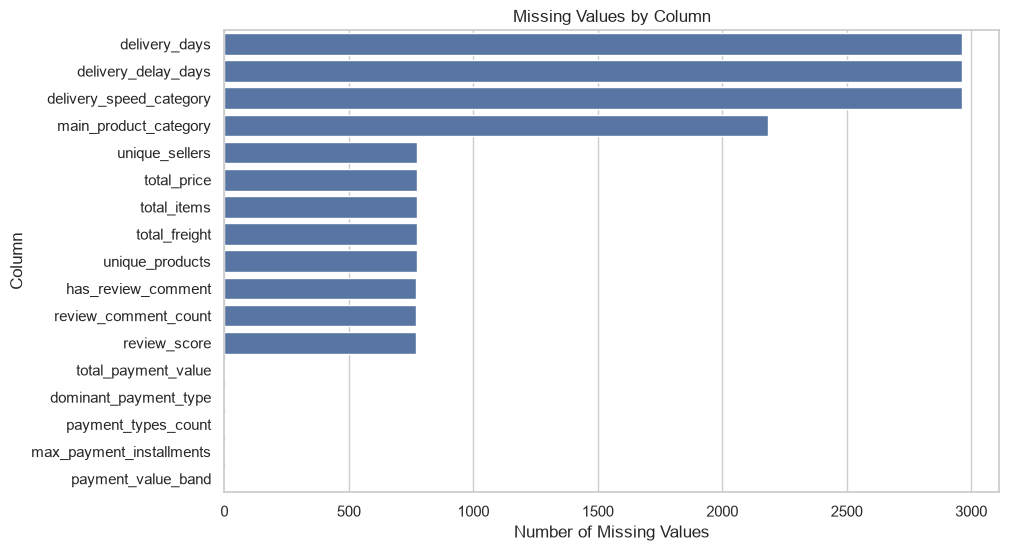

In [17]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=missing_values.values, y=missing_values.index)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.show()

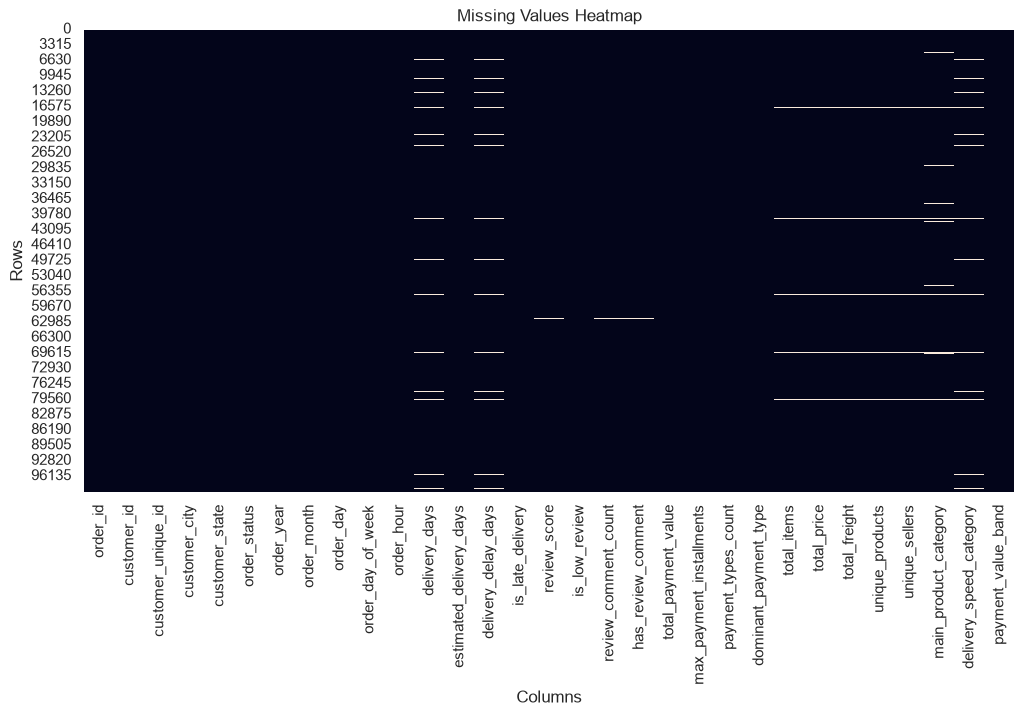

In [18]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

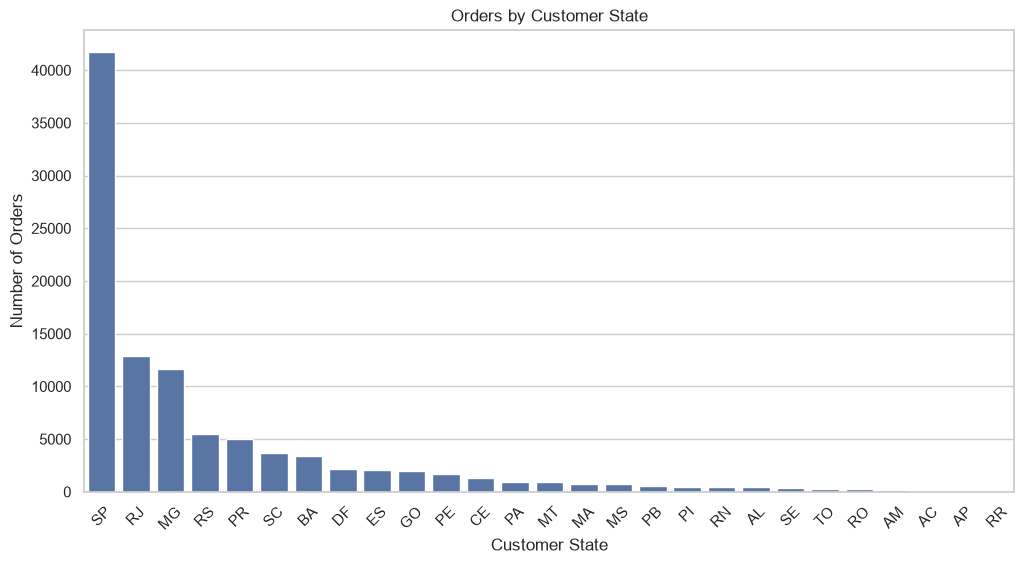

In [19]:
if "customer_state" in df.columns:
    plt.figure(figsize=(12,6))

    sns.countplot(
        data=df,
        x="customer_state",
        order=df["customer_state"].value_counts().index
    )

    plt.title("Orders by Customer State")
    plt.xlabel("Customer State")
    plt.ylabel("Number of Orders")
    plt.xticks(rotation=45)
    plt.show()

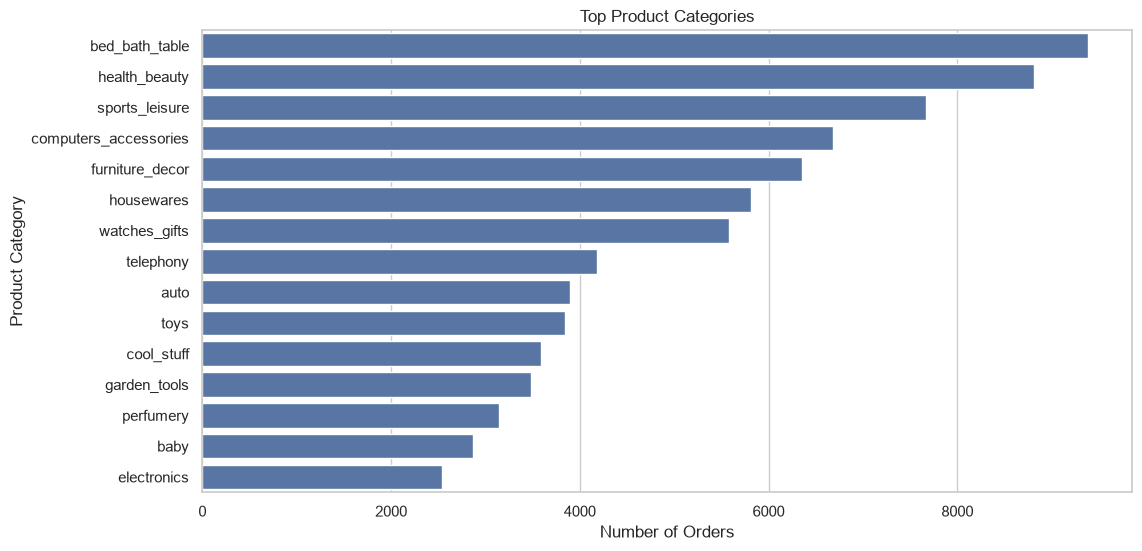

In [20]:

if "main_product_category" in df.columns:
    top_categories = df["main_product_category"].value_counts().head(15).index

    plt.figure(figsize=(12,6))

    sns.countplot(
        data=df[df["main_product_category"].isin(top_categories)],
        y="main_product_category",
        order=top_categories
    )

    plt.title("Top Product Categories")
    plt.xlabel("Number of Orders")
    plt.ylabel("Product Category")
    plt.show()

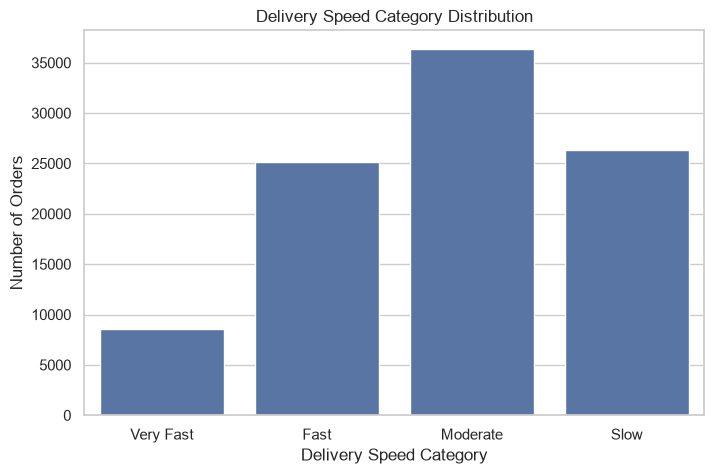

In [21]:
if "delivery_speed_category" in df.columns:

    delivery_order = [
        "Very Fast",
        "Fast",
        "Moderate",
        "Slow"
    ]

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x="delivery_speed_category",
        order=delivery_order
    )

    plt.title("Delivery Speed Category Distribution")
    plt.xlabel("Delivery Speed Category")
    plt.ylabel("Number of Orders")
    plt.show()

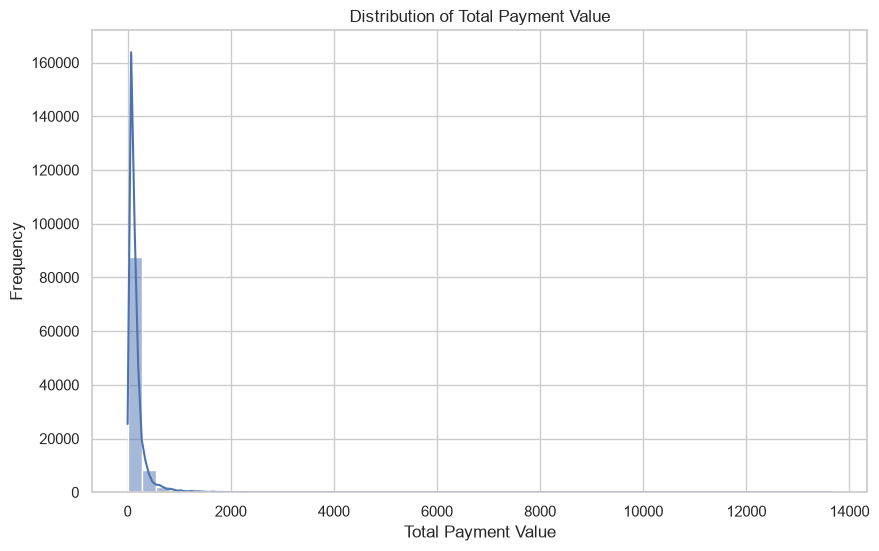

In [22]:
if "total_payment_value" in df.columns:

    plt.figure(figsize=(10,6))

    sns.histplot(
        data=df,
        x="total_payment_value",
        bins=50,
        kde=True
    )

    plt.title("Distribution of Total Payment Value")
    plt.xlabel("Total Payment Value")
    plt.ylabel("Frequency")
    plt.show()

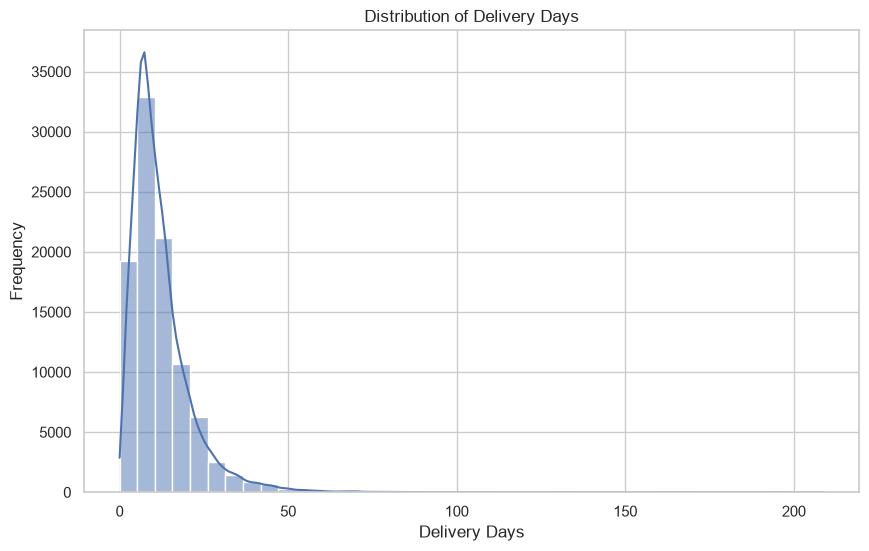

In [23]:
if "delivery_days" in df.columns:

    plt.figure(figsize=(10,6))

    sns.histplot(
        data=df,
        x="delivery_days",
        bins=40,
        kde=True
    )

    plt.title("Distribution of Delivery Days")
    plt.xlabel("Delivery Days")
    plt.ylabel("Frequency")
    plt.show()

In [24]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

skewness = df[numerical_columns].skew().sort_values(ascending=False)

skewness

total_freight               12.052723
unique_sellers               9.970926
total_price                  9.727741
total_payment_value          9.150169
unique_products              8.107218
total_items                  7.527006
payment_types_count          6.426400
delivery_days                3.828790
is_late_delivery             3.505337
delivery_delay_days          2.014360
is_low_review                2.013041
max_payment_installments     1.599412
estimated_delivery_days      0.987062
review_comment_count         0.379785
has_review_comment           0.349830
order_month                  0.206302
order_day_of_week            0.167725
order_day                    0.024266
order_year                  -0.236888
order_hour                  -0.601849
review_score                -1.364757
dtype: float64

In [25]:
skewness_df = pd.DataFrame({
    "Column": skewness.index,
    "Skewness": skewness.values
})

skewness_df

,Column,Skewness
0,total_freight,12.052723
1,unique_sellers,9.970926
2,total_price,9.727741
3,total_payment_value,9.150169
4,unique_products,8.107218
5,total_items,7.527006
6,payment_types_count,6.426400
7,delivery_days,3.828790
8,is_late_delivery,3.505337
9,delivery_delay_days,2.014360


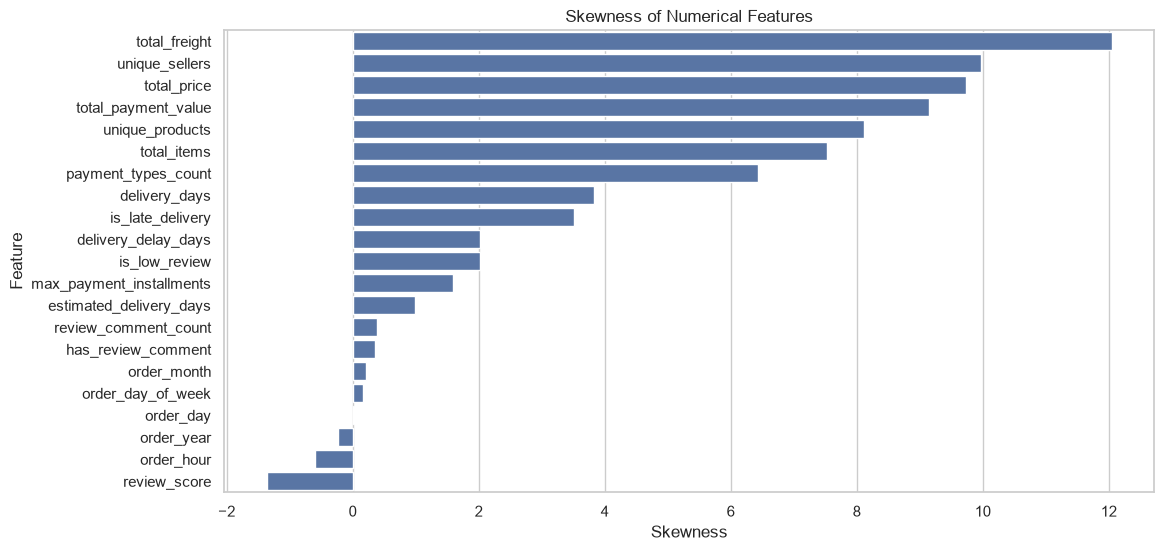

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=skewness_df,
    x="Skewness",
    y="Column"
)

plt.title("Skewness of Numerical Features")
plt.xlabel("Skewness")
plt.ylabel("Feature")

plt.show()

In [27]:
highly_skewed = skewness[abs(skewness) > 1]

print("Highly Skewed Features:")
print(highly_skewed)

Highly Skewed Features:
total_freight               12.052723
unique_sellers               9.970926
total_price                  9.727741
total_payment_value          9.150169
unique_products              8.107218
total_items                  7.527006
payment_types_count          6.426400
delivery_days                3.828790
is_late_delivery             3.505337
delivery_delay_days          2.014360
is_low_review                2.013041
max_payment_installments     1.599412
review_score                -1.364757
dtype: float64


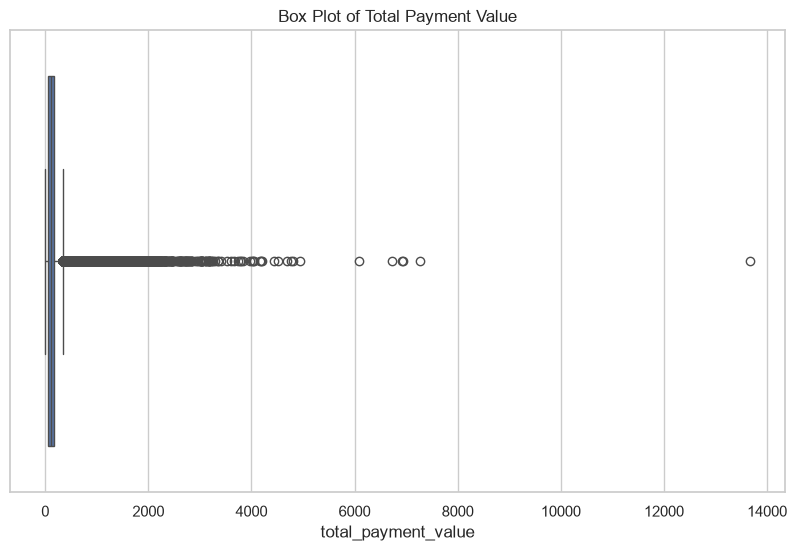

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["total_payment_value"]
)

plt.title("Box Plot of Total Payment Value")
plt.show()

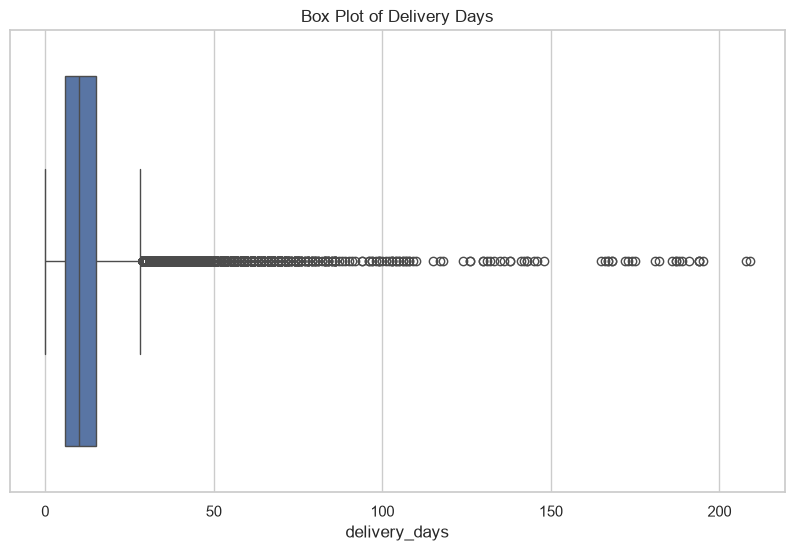

In [29]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["delivery_days"]
)

plt.title("Box Plot of Delivery Days")
plt.show()

In [30]:
Q1 = df["total_payment_value"].quantile(0.25)
Q3 = df["total_payment_value"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["total_payment_value"] < lower_bound) |
    (df["total_payment_value"] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 7866


In [31]:
outliers.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,...,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category,delivery_speed_category,payment_value_band
16,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,6e26bbeaa107ec34112c64e1ee31c0f5,rio de janeiro,RJ,delivered,2018,1,2,1,...,1.0,credit_card,1.0,1299.0,77.45,1.0,1.0,construction_tools_construction,Slow,Very High
38,434d158e96bdd6972ad6e6d73ddcfd22,2a1dfb647f32f4390e7b857c67458536,5f7d7732b351ce851a158528581af05f,jaboatao dos guararapes,PE,delivered,2018,6,1,4,...,1.0,boleto,1.0,445.0,63.17,1.0,1.0,health_beauty,Slow,Very High
41,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,3e4fd73f1e86b135b9b121d6abbe9597,presidente venceslau,SP,delivered,2017,11,24,4,...,1.0,credit_card,1.0,339.0,17.12,1.0,1.0,housewares,Slow,Very High
53,641fb0752bf5b5940c376b3a8bb9dc52,f5afca14dfa9dc64251cf2b45c54c363,38cad70d154a4dcc42b598d5c01f7ef1,duque de caxias,RJ,delivered,2017,12,15,4,...,1.0,credit_card,1.0,369.0,17.33,1.0,1.0,watches_gifts,Slow,Very High
65,f271576bed568e896f99eb710cd3a6f8,5dda11942d4f77bee3a46d71e442aec4,6a0e43f0d7e1b5539e4c58a26ebe35da,boninal,BA,delivered,2018,1,7,6,...,1.0,credit_card,2.0,659.8,164.96,1.0,1.0,construction_tools_construction,Moderate,Very High


In [32]:
outlier_percentage = (len(outliers) / len(df)) * 100

print(f"Outlier Percentage: {outlier_percentage:.2f}%")

Outlier Percentage: 7.91%


In [33]:
numerical_df = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numerical_df.corr()

correlation_matrix

,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,...,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,total_items,total_price,total_freight,unique_products,unique_sellers
order_year,1.000000,-0.550059,-0.043672,-0.017917,-0.003229,-0.050156,-0.142717,0.067070,0.044052,0.004872,...,-0.020369,-0.019840,-0.000183,-0.059538,-0.019503,0.000211,-0.002716,0.027865,-0.004688,0.017861
order_month,-0.550059,1.000000,0.001343,0.020588,-0.003953,-0.054398,-0.094182,0.025640,-0.030097,0.027560,...,-0.009445,-0.008929,0.002795,0.030311,0.003532,0.000457,0.001993,0.003800,0.009030,0.004820
order_day,-0.043672,0.001343,1.000000,-0.024895,-0.012195,-0.000528,-0.030391,0.024665,0.007092,0.001774,...,-0.002527,-0.002751,-0.008652,0.001596,0.002613,0.011453,-0.007884,-0.008286,0.006638,0.002989
order_day_of_week,-0.017917,0.020588,-0.024895,1.000000,0.009433,0.028807,0.067685,-0.031395,-0.011613,-0.008246,...,-0.003897,-0.004271,-0.002538,0.026230,-0.000564,-0.011766,-0.002625,-0.002400,0.004694,0.011540
order_hour,-0.003229,-0.003953,-0.012195,0.009433,1.000000,-0.004758,-0.000144,0.022651,0.007205,0.005765,...,-0.009375,-0.009162,0.004185,0.013405,0.005917,-0.009770,0.004538,0.000074,0.003316,-0.003613
delivery_days,-0.050156,-0.054398,-0.000528,0.028807,-0.004758,1.000000,0.382836,0.607716,0.603732,-0.334150,...,0.085097,0.084981,0.069496,0.051852,0.001487,-0.019167,0.055466,0.167077,-0.029999,-0.040664
estimated_delivery_days,-0.142717,-0.094182,-0.030391,0.067685,-0.000144,0.382836,1.000000,-0.499649,-0.033475,-0.054533,...,0.044501,0.043892,0.094915,0.094111,0.011618,0.015000,0.076126,0.237994,0.022900,0.023690
delivery_delay_days,0.067070,0.025640,0.024665,-0.031395,0.022651,0.607716,-0.499649,1.000000,0.595474,-0.266990,...,0.042127,0.042589,-0.017743,-0.030909,-0.008432,-0.031915,-0.013443,-0.049303,-0.047724,-0.059083
is_late_delivery,0.044052,-0.030097,0.007092,-0.011613,0.007205,0.603732,-0.033475,0.595474,1.000000,-0.354495,...,0.093407,0.093849,0.018104,0.012076,-0.003983,-0.014851,0.016587,0.029797,-0.021231,-0.025332
review_score,0.004872,0.027560,0.001774,-0.008246,0.005765,-0.334150,-0.054533,-0.266990,-0.354495,1.000000,...,-0.258592,-0.259388,-0.049137,-0.031006,-0.001868,-0.115559,-0.039724,-0.088623,-0.097079,-0.107921


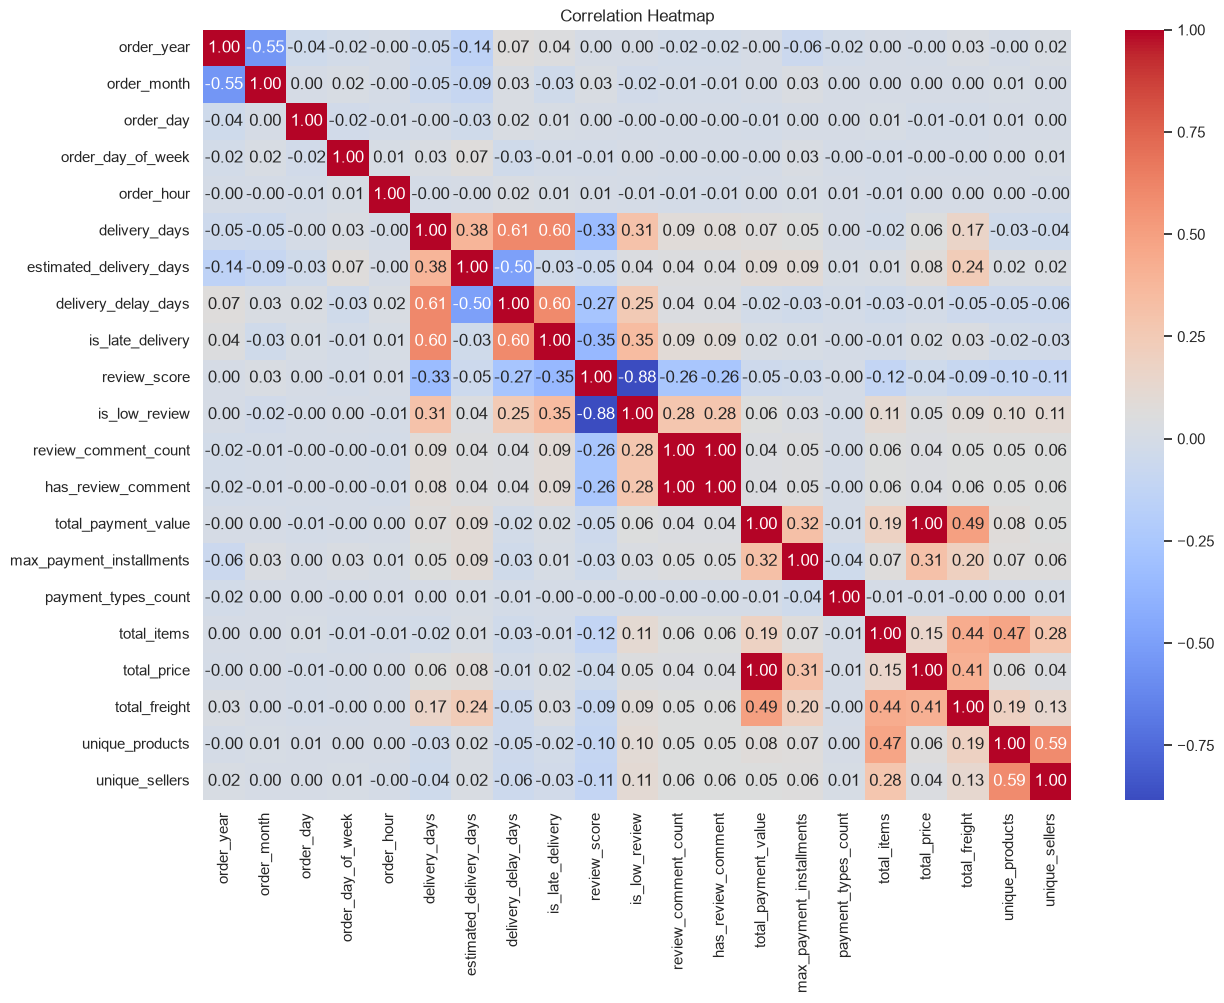

In [35]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [36]:
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)

corr_pairs = corr_pairs[corr_pairs != 1]

corr_pairs.head(20)

has_review_comment    review_comment_count    0.997057
review_comment_count  has_review_comment      0.997057
total_price           total_payment_value     0.995970
total_payment_value   total_price             0.995970
delivery_delay_days   delivery_days           0.607716
delivery_days         delivery_delay_days     0.607716
                      is_late_delivery        0.603732
is_late_delivery      delivery_days           0.603732
                      delivery_delay_days     0.595474
delivery_delay_days   is_late_delivery        0.595474
unique_products       unique_sellers          0.592784
unique_sellers        unique_products         0.592784
total_payment_value   total_freight           0.492681
total_freight         total_payment_value     0.492681
total_items           unique_products         0.470977
unique_products       total_items             0.470977
total_items           total_freight           0.436941
total_freight         total_items             0.436941
total_pric

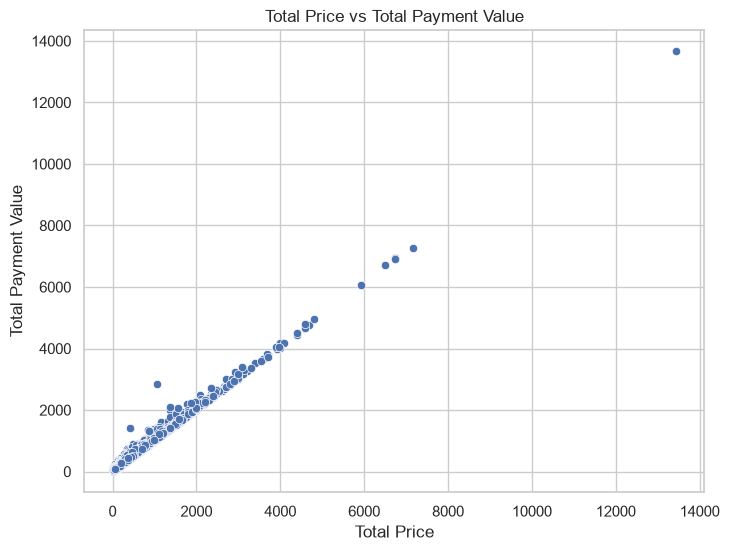

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="total_price",
    y="total_payment_value"
)

plt.title("Total Price vs Total Payment Value")
plt.xlabel("Total Price")
plt.ylabel("Total Payment Value")

plt.show()

In [38]:
df.to_csv("../data/processed/olist_orders_abt_lab03.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
